# TF-IDF Demo
A simple demonstration of **Term Frequency – Inverse Document Frequency (TF-IDF)** scoring from scratch using NumPy.

In [1]:
import numpy as np

## Documents
Define the corpus as a list of tokenised sentences.

In [2]:
a = "purple is the best city in the forest".split()
b = "there is an art to getting your way and throwing bananas on to the street is not it".split()
c = "it is not often you find soggy bananas on the street".split()

docs = [a, b, c]
docs

[['purple', 'is', 'the', 'best', 'city', 'in', 'the', 'forest'],
 ['there',
  'is',
  'an',
  'art',
  'to',
  'getting',
  'your',
  'way',
  'and',
  'throwing',
  'bananas',
  'on',
  'to',
  'the',
  'street',
  'is',
  'not',
  'it'],
 ['it',
  'is',
  'not',
  'often',
  'you',
  'find',
  'soggy',
  'bananas',
  'on',
  'the',
  'street']]

In [15]:
# vocab = sorted(set(word.lower() for doc in docs for word in doc))
vocab = set(a+b+c)

print(f'Vocabulary size: {len(vocab)}')
print(vocab)

Vocabulary size: 25
{'art', 'is', 'to', 'often', 'purple', 'not', 'street', 'in', 'best', 'bananas', 'the', 'your', 'way', 'it', 'there', 'an', 'find', 'and', 'throwing', 'soggy', 'getting', 'on', 'city', 'forest', 'you'}


In [17]:
def tfidf_vector(doc):
    return np.array([tfidf(word)["tfidf"][docs.index(doc)] for word in vocab])

vec_a = tfidf_vector(a)
vec_b = tfidf_vector(b)
vec_c = tfidf_vector(c)

print("vec_a (doc a):")
for word, score in zip(vocab, vec_a):
    print(f"  {word:<12} {score:.4f}")

print("\nvec_b (doc b):")
for word, score in zip(vocab, vec_b):
    print(f"  {word:<12} {score:.4f}")

print("\nvec_c (doc c):")
for word, score in zip(vocab, vec_c):
    print(f"  {word:<12} {score:.4f}")

vec_a (doc a):
  art          0.0000
  is           0.1250
  to           0.0000
  often        0.0000
  purple       0.2116
  not          0.0000
  street       0.0000
  in           0.2116
  best         0.2116
  bananas      0.0000
  the          0.2500
  your         0.0000
  way          0.0000
  it           0.0000
  there        0.0000
  an           0.0000
  find         0.0000
  and          0.0000
  throwing     0.0000
  soggy        0.0000
  getting      0.0000
  on           0.0000
  city         0.2116
  forest       0.2116
  you          0.0000

vec_b (doc b):
  art          0.0941
  is           0.1111
  to           0.1881
  often        0.0000
  purple       0.0000
  not          0.0715
  street       0.0715
  in           0.0000
  best         0.0000
  bananas      0.0715
  the          0.0556
  your         0.0941
  way          0.0941
  it           0.0715
  there        0.0941
  an           0.0941
  find         0.0000
  and          0.0941
  throwing     0.0941
 

## TF-IDF Function
Given a word, compute:
- **TF** (term frequency) per document
- **IDF** (inverse document frequency) across the corpus
- **TF-IDF** = TF × IDF

In [3]:
def tfidf(word):
    word = word.lower()
    N = len(docs)

    # --- Term Frequency (TF) ---
    tf = np.array([
        doc.count(word) / len(doc)
        for doc in docs
    ])

    # --- Document Frequency (DF) ---
    df = sum(1 for doc in docs if word in doc)

    # --- Inverse Document Frequency (IDF) ---
    # add small epsilon to avoid division by zero
    idf = np.log((N + 1) / (df + 1)) + 1

    # --- TF-IDF ---
    tfidf_scores = tf * idf

    return {
        "tf": tf,
        "idf": idf,
        "tfidf": tfidf_scores
    }

In [4]:
# For a fixed word, IDF is constant, so TF-IDF should grow linearly with TF.
fixed_word = "bananas"
idf_fixed = tfidf(fixed_word)["idf"]

tf_values = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
tfidf_values = tf_values * idf_fixed

print(f"Word: {fixed_word}")
print(f"Fixed IDF: {idf_fixed:.4f}")
print("\nTF -> TF-IDF")
for tf_val, tfidf_val in zip(tf_values, tfidf_values):
    print(f"{tf_val:.1f} -> {tfidf_val:.4f}")

# In a linear relation y = m*x, the ratio y/x is constant (= m) for x > 0.
ratios = tfidf_values[1:] / tf_values[1:]
print("\nTF-IDF / TF (x>0):", np.round(ratios, 4))

Word: bananas
Fixed IDF: 1.2877

TF -> TF-IDF
0.0 -> 0.0000
0.1 -> 0.1288
0.2 -> 0.2575
0.3 -> 0.3863
0.4 -> 0.5151
0.5 -> 0.6438

TF-IDF / TF (x>0): [1.2877 1.2877 1.2877 1.2877 1.2877]


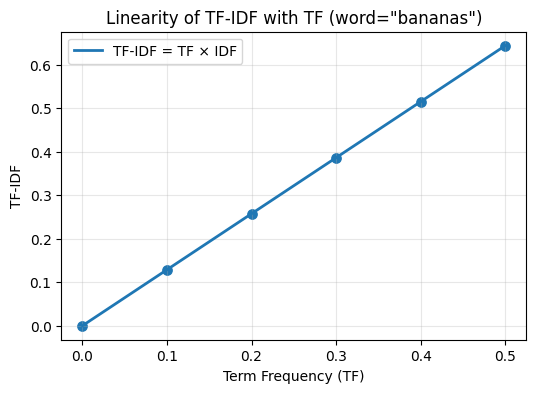

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(tf_values, tfidf_values, '-', linewidth=2, label='TF-IDF = TF × IDF')
plt.scatter(tf_values, tfidf_values, s=45)
plt.title(f'Linearity of TF-IDF with TF (word="{fixed_word}")')
plt.xlabel('Term Frequency (TF)')
plt.ylabel('TF-IDF')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Demo: Single Word
Compute TF-IDF scores for the word **"bananas"**.

In [ ]:
result = tfidf("bananas")
print("TF:    ", result["tf"])
print("IDF:   ", result["idf"])
print("TF-IDF:", result["tfidf"])

## Demo: Multiple Words
Compute TF-IDF scores for several words across the corpus.

In [ ]:
words = ["bananas", "street", "is", "purple"]
for word in words:
    result = tfidf(word)
    print(f"\nWord: '{word}'")
    print(f"  TF:     {result['tf']}")
    print(f"  IDF:    {result['idf']:.4f}")
    print(f"  TF-IDF: {result['tfidf']}")